# Intro to the API

Start with LFADS on a Lorenz dataset with 20 neurons, then run NDT, MINT,
and CASSM on the same data. All models are trained from scratch.

Open this notebook in Jupyter with NLB2, NumPy, and Matplotlib installed in the
kernel's Python environment. Run the cells in order from the `tutorials/`
directory. Everything runs on CPU, and no data download is needed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from nlb2 import Experiment, ExperimentConfig, PreprocessingConfig
from nlb2.datasets import LorenzDatasetConfig
from nlb2.models import LFADSConfig
from nlb2.training import TrainerConfig

## Configure the experiment

Lorenz dynamics generate firing rates for 20 simulated neurons; Poisson sampling
turns those rates into spike counts. Training and validation use separate trials
of the same underlying trajectories.

`ExperimentConfig` combines the dataset, model, preprocessing, and training
settings. LFADS uses its standard Lorenz model settings, including 20 factors,
and trains on raw spike counts. The seeds fix the data, training randomness,
and evaluation sampling.

In [2]:
config = ExperimentConfig(
    dataset=LorenzDatasetConfig(
        neurons=20,
        num_inits=2,
        num_trials=8,
        num_steps=60,
        seed=0,
    ),
    model=LFADSConfig(),
    preprocessing=PreprocessingConfig(),
    trainer=TrainerConfig(epochs=200, device="cpu", live_eval_interval=20),
    batch_size=4,
    output_dir="runs/lorenz_tutorial",
    run_name="lfads",
    evaluation_seed=0,
)

## Train and evaluate

`Experiment.run()` prepares the data, builds and trains the model, evaluates it
on validation trials, and saves the run. The returned result contains the
learning history, evaluation metrics, and artifact paths.

Every 20 epochs, it also evaluates rate reconstruction on the validation trials.

In [3]:
%%capture --no-stderr
result = Experiment(config).run()

## Plot learning curves

LFADS minimizes an ELBO-based objective that combines spike-count reconstruction
with latent regularization. Lower loss is better; validation evaluates trials
excluded from training.

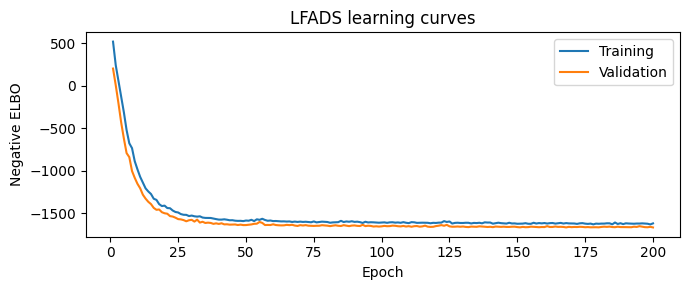

In [4]:
epochs = [report.epoch + 1 for report in result.history]
train_loss = [report.train.loss for report in result.history]
valid_loss = [report.valid.loss for report in result.history]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(epochs, train_loss, label="Training")
ax.plot(epochs, valid_loss, label="Validation")
ax.set(xlabel="Epoch", ylabel="Negative ELBO", title="LFADS learning curves")
ax.xaxis.get_major_locator().set_params(integer=True)
ax.legend()
fig.tight_layout()
plt.show()

## Inspect reconstructed activity

The saved predictions contain the model's estimated rates and the known Lorenz
rates for the validation trials. Compare them for one neuron in the first
validation trial. Ground-truth rates are used for evaluation, not training.

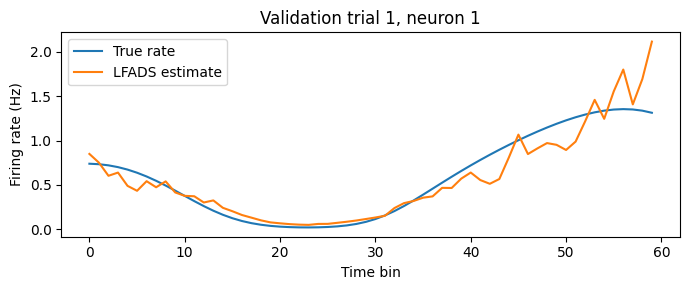

In [5]:
with np.load(result.predictions_path) as predictions:
    true_rates = predictions["target_rates"][0, :, 0]
    predicted_rates = predictions["pred_rates"][0, :, 0]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(true_rates, label="True rate")
ax.plot(predicted_rates, label="LFADS estimate")
ax.set(xlabel="Time bin", ylabel="Firing rate (Hz)", title="Validation trial 1, neuron 1")
ax.legend()
fig.tight_layout()
plt.show()

## Inspect the results

The run folder includes `config.json`, `history.csv`, `metrics.json`,
`model.pt`, and `predictions.npz`. The metrics below include rate reconstruction
error and latent reconstruction quality.

In [6]:
print(f"Run saved to: {result.run_dir}")
result.metrics

Run saved to: runs/lorenz_tutorial/lfads-5


{'co_bps': 1.1610225439071655,
 'poisson_nll': -1.4048558473587036,
 'rate_mse': 0.1981763243675232,
 'rate_r2': 0.9907048344612122,
 'latent_linear_r2': 0.9962155509799101}

## Run NDT, MINT, and CASSM

Load each method's [Lorenz recipe](../configs/experiment/synthetic/lorenz), then
reuse our 20-neuron dataset. The recipes supply the model settings and
preprocessing, including CASSM's input smoothing.

NDT and CASSM train for 200 epochs, and MINT trains for 50 epochs.
Every call to `Experiment.run()` below trains a new model.

In [7]:
from dataclasses import replace
from pathlib import Path

from nlb2 import load_experiment_config

recipe_root = Path("../configs/experiment/synthetic/lorenz")
recipes = {
    "NDT": load_experiment_config(recipe_root / "ndt/ndt_lorenz.yaml"),
    "MINT": load_experiment_config(recipe_root / "mint/mint_lorenz_100.yaml"),
    "CASSM": load_experiment_config(recipe_root / "cassm/cassm_lorenz.yaml"),
}
comparison_configs = {
    name: replace(
        recipe,
        dataset=config.dataset,
        trainer=replace(
            config.trainer,
            epochs=recipe.trainer.epochs if name == "MINT" else config.trainer.epochs,
        ),
        batch_size=config.batch_size,
        evaluation_seed=config.evaluation_seed,
        output_dir=str(result.run_dir / "comparison"),
        run_name=name.lower(),
    )
    for name, recipe in recipes.items()
}

In [8]:
%%capture --no-stderr
comparison_results = {
    name: Experiment(model_config).run()
    for name, model_config in comparison_configs.items()
}

## Inspect the three runs

Plot each model's training and validation loss.

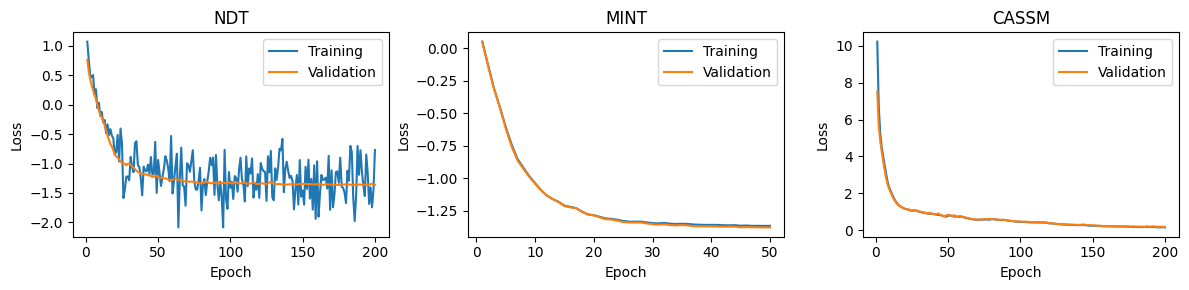

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for ax, (name, model_result) in zip(axes, comparison_results.items()):
    epochs = [report.epoch + 1 for report in model_result.history]
    ax.plot(epochs, [report.train.loss for report in model_result.history], label="Training")
    ax.plot(epochs, [report.valid.loss for report in model_result.history], label="Validation")
    ax.set(title=name, xlabel="Epoch", ylabel="Loss")
    ax.xaxis.get_major_locator().set_params(integer=True)
    ax.legend()

fig.tight_layout()
plt.show()

Compare the estimated rates for the same validation trial and neuron shown above.

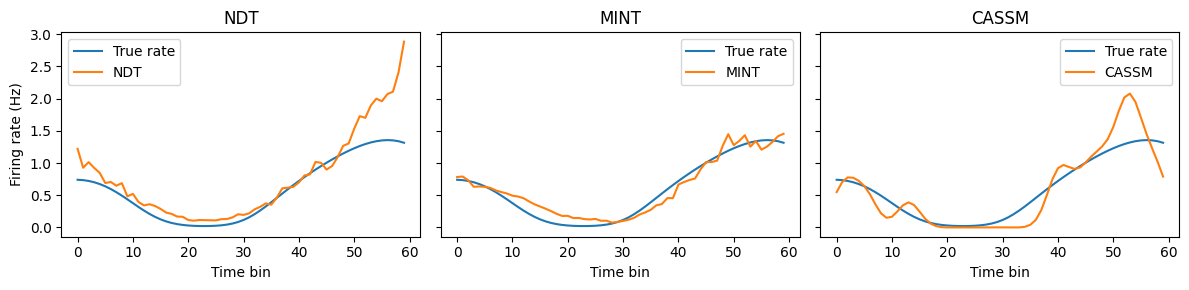

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

for ax, (name, model_result) in zip(axes, comparison_results.items()):
    with np.load(model_result.predictions_path) as predictions:
        ax.plot(predictions["target_rates"][0, :, 0], label="True rate")
        ax.plot(predictions["pred_rates"][0, :, 0], label=name)
    ax.set(title=name, xlabel="Time bin")
    ax.legend()

axes[0].set_ylabel("Firing rate (Hz)")
fig.tight_layout()
plt.show()

## Compare rate reconstruction

Rate mean squared error (MSE) provides a common metric across methods. These
values average over every validation trial, time bin, and neuron; lower is better.

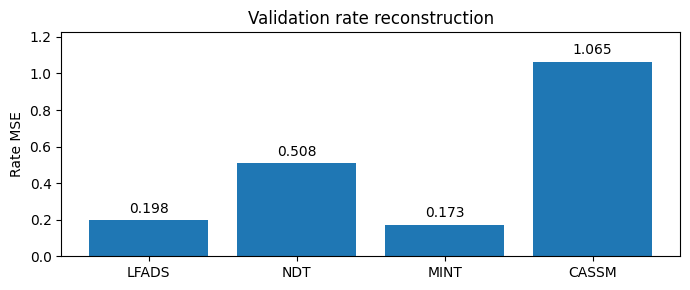

In [11]:
all_results = {"LFADS": result, **comparison_results}

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(
    list(all_results),
    [model_result.metrics["rate_mse"] for model_result in all_results.values()],
)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.margins(y=0.15)
ax.set(ylabel="Rate MSE", title="Validation rate reconstruction")
fig.tight_layout()
plt.show()

## Reproduce the three runs with one command

The CLI accepts several YAML recipes or saved `config.json` files in one
invocation and runs them sequentially. The command below uses the exact
configurations saved by the three comparison runs, including the 20-neuron
dataset and each model's settings.

After executing the cells above, run the printed command from the notebook's
directory to train on a CUDA GPU. Use
`--device cpu` to run on CPU.

In [12]:
config_paths = " ".join(str(run.config_path) for run in comparison_results.values())
print(f"nlb2 run -c {config_paths} --device cuda")

nlb2 run -c runs/lorenz_tutorial/lfads-5/comparison/ndt/config.json runs/lorenz_tutorial/lfads-5/comparison/mint/config.json runs/lorenz_tutorial/lfads-5/comparison/cassm/config.json --device cuda


Try changing the LFADS factor count, a model's size, or the training budget and
rerun from the relevant configuration cell. For other models and configuration
options, see the [NLB2 documentation](https://zkunkworks.com/nlb2/).